# Tugas Praktikum

## 1. Tugas K-Means

### Membaca Dataset Mall_Customers.csv

In [50]:
import pandas as pd

df = pd.read_csv('Mall_Customers.csv')

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [51]:
# Mengecek struktur datanya:

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


### Menentukan Fitur untuk Clustering

In [52]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


Fitur Annual Income (k$) dan Spending Score (1-100) dipilih karena keduanya dapat menggambarkan karakteristik pelanggan dari sisi pendapatan dan perilaku belanja.

### Melihat Persebaran Data

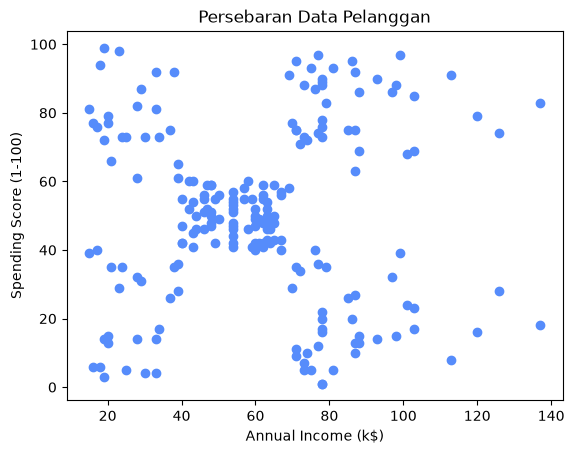

In [53]:
import matplotlib.pyplot as plt

plt.scatter(
    X['Annual Income (k$)'],
    X['Spending Score (1-100)']
)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Persebaran Data Pelanggan')
plt.show()

Visualisasi awal ini digunakan untuk melihat pola persebaran data sebelum dilakukan clustering.

### Menentukan Jumlah k Terbaik

In [54]:
# Menggunakan Elbow Method
from sklearn.cluster import KMeans

inertia = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=0,
        n_init=10
    )

    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

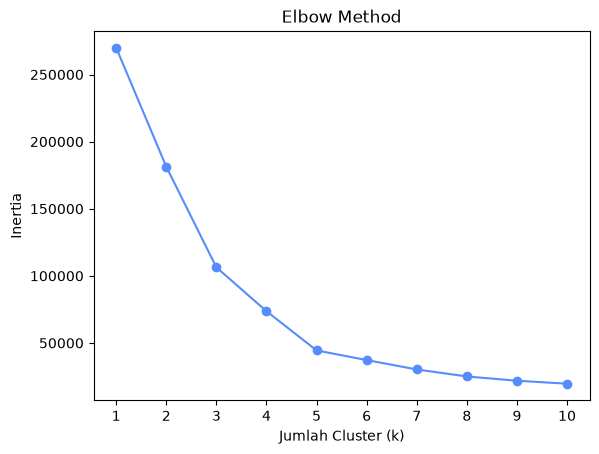

In [55]:
# Visualisasi
plt.plot(
    range(1, 11),
    inertia,
    marker='o'
)

plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.xticks(range(1, 11))
plt.show()

Berdasarkan grafik Elbow Method, nilai k = 5 dipilih sebagai jumlah cluster yang digunakan. Hal ini karena penurunan nilai inertia cukup signifikan dari k=1 hingga k=5, sedangkan setelah k=5 penurunannya mulai melandai. Oleh karena itu, 5 cluster dipertimbangkan sebagai jumlah cluster yang sesuai untuk model K-Means.

### Menentukan k

In [56]:
k = 5

### Membuat Model K-Means

In [57]:
kmeans = KMeans(
    n_clusters=5,
    random_state=0,
    n_init=10
)

labels = kmeans.fit_predict(X)

print(labels)

[3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3
 4 3 4 3 4 3 0 3 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 2 1 0 1 2 1 2 1 0 1 2 1 2 1 2 1 2 1 0 1 2 1 2 1
 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2
 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1]


### Memasukkan Hasil Cluster ke Dataset

In [58]:
df['Cluster'] = labels

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,3
1,2,Male,21,15,81,4
2,3,Female,20,16,6,3
3,4,Female,23,16,77,4
4,5,Female,31,17,40,3


In [59]:
# Melihat jumlah anggota setiap cluster
df['Cluster'].value_counts().sort_index()

Cluster
0    81
1    39
2    35
3    23
4    22
Name: count, dtype: int64

### Memvisualisasi Hasil K-Means

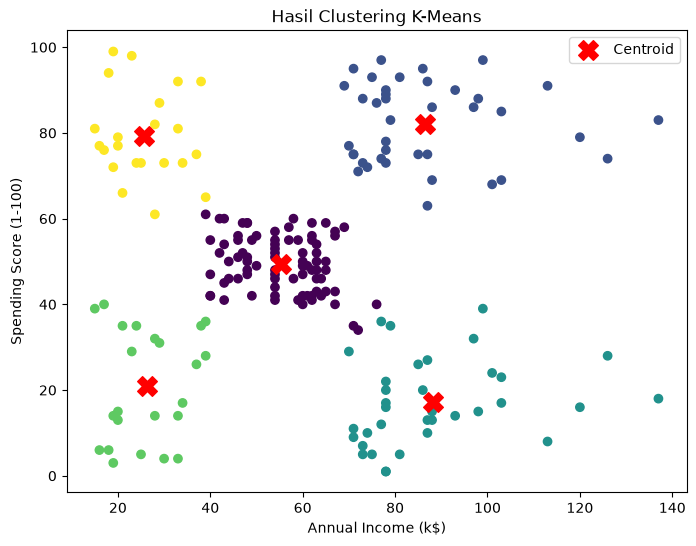

In [60]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X['Annual Income (k$)'],
    X['Spending Score (1-100)'],
    c=labels,
    cmap='viridis'
)

plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=200,
    c='red',
    marker='X',
    label='Centroid'
)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Hasil Clustering K-Means')
plt.legend()

plt.show()

Berdasarkan hasil Elbow Method, diperoleh jumlah cluster terbaik yaitu k = 5. Pada titik tersebut, penurunan nilai inertia mulai melandai dibandingkan nilai k sebelumnya. Oleh karena itu, model K-Means menggunakan 5 cluster untuk mengelompokkan pelanggan berdasarkan fitur Annual Income (k$) dan Spending Score (1-100).

## 2. Tugas DBSCAN

### 1. Membuat dataset make_moons (1000 sampel, noise=0.05), lalu normalisasi.

In [61]:
# Import library untuk membuat dataset sintetis
from sklearn.datasets import make_moons

# Import StandardScaler untuk normalisasi/standardisasi data
from sklearn.preprocessing import StandardScaler

# Import matplotlib untuk visualisasi
import matplotlib.pyplot as plt

Membuat dataset

In [62]:
# Membuat dataset make_moons sebanyak 1000 sampel dengan noise 0.05
X, labels_true = make_moons(
    n_samples=1000,
    noise=0.05,
    random_state=0
)

# Menampilkan ukuran dataset
print("Ukuran dataset:", X.shape)

Ukuran dataset: (1000, 2)


Normalisasi data

In [63]:
# Melakukan standardisasi agar kedua fitur memiliki skala yang sebanding
X = StandardScaler().fit_transform(X)

# Menampilkan 5 data pertama setelah standardisasi
print(X[:5])

[[ 1.75081891  0.48393978]
 [ 1.35606443 -0.90706929]
 [-0.90150442  1.22470664]
 [-0.60117222 -0.14688373]
 [ 0.0048725  -1.28700543]]


Visualisasi dataset

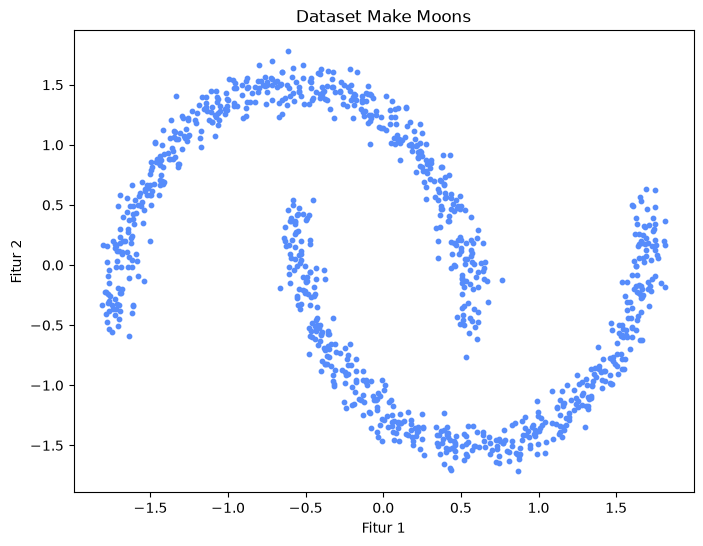

In [64]:
# Membuat scatter plot dataset make_moons
plt.figure(figsize=(8, 6))

# X[:, 0] = fitur pertama dan X[:, 1] = fitur kedua
plt.scatter(X[:, 0], X[:, 1], s=10)

# Memberikan judul pada grafik
plt.title('Dataset Make Moons')

# Memberikan nama sumbu
plt.xlabel('Fitur 1')
plt.ylabel('Fitur 2')

# Menampilkan grafik
plt.show()

### 2. Menjalankan DBSCAN dengan eps=0.2, min_samples=5, hitung jumlah klaster & noise.

Membuat Model DBSCAN

In [65]:
# Import algoritma DBSCAN
from sklearn.cluster import DBSCAN

# Membuat dan menjalankan DBSCAN
db = DBSCAN(
    eps=0.2,
    min_samples=5
).fit(X)

# Mengambil label cluster hasil DBSCAN
labels = db.labels_

Menghitung jumlah cluster dan noise

In [66]:
# Menghitung jumlah cluster dan mengabaikan label -1 (noise)
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)

# Menghitung jumlah titik yang memiliki label -1
n_noise_ = list(labels).count(-1)

# Menampilkan hasil
print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

Estimated number of clusters: 2
Estimated number of noise points: 0


### 3. Meng-evaluasi dengan metrik: Homogeneity, Completeness, V-measure, ARI, AMI, Silhouette.

In [67]:
# Import metrics untuk mengevaluasi hasil clustering
from sklearn import metrics

Menghitung metrik evaluasi

In [68]:
# Mengukur apakah setiap cluster hanya berisi anggota dari kelas yang sama
homogeneity = metrics.homogeneity_score(labels_true, labels)

# Mengukur apakah anggota kelas yang sama berada pada cluster yang sama
completeness = metrics.completeness_score(labels_true, labels)

# Kombinasi antara Homogeneity dan Completeness
v_measure = metrics.v_measure_score(labels_true, labels)

# Mengukur kesamaan antara hasil clustering dan label asli
ari = metrics.adjusted_rand_score(labels_true, labels)

# Mengukur kesamaan informasi antara hasil clustering dan label asli
ami = metrics.adjusted_mutual_info_score(labels_true, labels)

# Mengukur seberapa rapat dan terpisah cluster yang terbentuk
silhouette = metrics.silhouette_score(X, labels)

# Menampilkan hasil evaluasi
print("Homogeneity: %0.3f" % homogeneity)
print("Completeness: %0.3f" % completeness)
print("V-measure: %0.3f" % v_measure)
print("Adjusted Rand Index: %0.3f" % ari)
print("Adjusted Mutual Information: %0.3f" % ami)
print("Silhouette Coefficient: %0.3f" % silhouette)

Homogeneity: 1.000
Completeness: 1.000
V-measure: 1.000
Adjusted Rand Index: 1.000
Adjusted Mutual Information: 1.000
Silhouette Coefficient: 0.392


### 4. Mem-visualisasikan hasil DBSCAN (core sample = titik besar, non-core = titik kecil, noise = hitam).

Menentukan core sample

In [69]:
# Import numpy
import numpy as np

# Membuat array boolean untuk menandai core sample
core_samples_mask = np.zeros_like(labels, dtype=bool)

# Posisi core sample diubah menjadi True
core_samples_mask[db.core_sample_indices_] = True

# Mengambil semua label cluster yang unik
unique_labels = set(labels)

Visualisasi

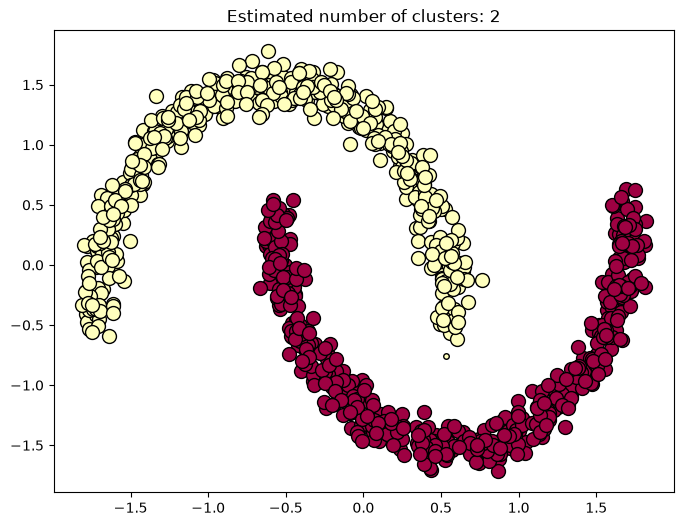

In [70]:
# Membuat area grafik
plt.figure(figsize=(8, 6))

# Melakukan perulangan untuk setiap cluster
for k in unique_labels:

    # Jika label -1, titik merupakan noise dan diberi warna hitam
    if k == -1:
        col = [0, 0, 0, 1]
    else:
        # Cluster selain noise mendapatkan warna yang berbeda
        col = plt.cm.Spectral(float(k) / n_clusters_)

    # Menentukan data yang termasuk cluster k
    class_member_mask = labels == k

    # Mengambil core sample pada cluster k
    xy = X[class_member_mask & core_samples_mask]

    # Core sample digambar dengan ukuran besar
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        'o',
        markerfacecolor=tuple(col),
        markeredgecolor='k',
        markersize=10
    )

    # Mengambil non-core sample pada cluster k
    xy = X[class_member_mask & ~core_samples_mask]

    # Non-core sample digambar dengan ukuran kecil
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        'o',
        markerfacecolor=tuple(col),
        markeredgecolor='k',
        markersize=4
    )

# Memberikan judul grafik
plt.title('Estimated number of clusters: %d' % n_clusters_)

# Menampilkan grafik
plt.show()

### 5. Melakukan eksperimen

Menentukan parameter

In [71]:
# Daftar nilai eps yang akan diuji
eps_values = [0.05, 0.1, 0.3, 0.5]

# Daftar nilai min_samples yang akan diuji
min_samples_values = [3, 10, 20]

Menjalankan semua kombinasi

In [72]:
# List untuk menyimpan seluruh hasil eksperimen
results = []

# Mencoba setiap nilai eps
for eps in eps_values:

    # Mencoba setiap nilai min_samples
    for min_samples in min_samples_values:

        # Membuat model DBSCAN berdasarkan parameter yang sedang diuji
        db_exp = DBSCAN(
            eps=eps,
            min_samples=min_samples
        ).fit(X)

        # Mengambil label hasil clustering
        labels_exp = db_exp.labels_

        # Menghitung jumlah cluster
        n_clusters = len(set(labels_exp)) - (
            1 if -1 in labels_exp else 0
        )

        # Menghitung jumlah noise
        n_noise = list(labels_exp).count(-1)

        # Menghitung metrik evaluasi
        homogeneity = metrics.homogeneity_score(
            labels_true, labels_exp
        )

        completeness = metrics.completeness_score(
            labels_true, labels_exp
        )

        v_measure = metrics.v_measure_score(
            labels_true, labels_exp
        )

        ari = metrics.adjusted_rand_score(
            labels_true, labels_exp
        )

        ami = metrics.adjusted_mutual_info_score(
            labels_true, labels_exp
        )

        # Silhouette hanya dapat dihitung jika cluster yang terbentuk > 1
        if n_clusters > 1:
            silhouette = metrics.silhouette_score(
                X, labels_exp
            )
        else:
            silhouette = np.nan

        # Menyimpan hasil eksperimen
        results.append([
            eps,
            min_samples,
            n_clusters,
            n_noise,
            homogeneity,
            completeness,
            v_measure,
            ari,
            ami,
            silhouette
        ])

Membuat tabel hasil eksperimen

In [73]:
# Mengubah hasil eksperimen menjadi DataFrame
results_df = pd.DataFrame(
    results,
    columns=[
        'eps',
        'min_samples',
        'Jumlah Cluster',
        'Jumlah Noise',
        'Homogeneity',
        'Completeness',
        'V-measure',
        'ARI',
        'AMI',
        'Silhouette'
    ]
)

# Menampilkan seluruh hasil eksperimen
results_df

,eps,min_samples,Jumlah Cluster,Jumlah Noise,Homogeneity,Completeness,V-measure,ARI,AMI,Silhouette
0,0.05,3,67,197,0.803825,0.154915,0.259767,0.032984,0.246428,0.077967
1,0.05,10,0,1000,0.000000,1.000000,0.000000,0.000000,0.000000,NaN
2,0.05,20,0,1000,0.000000,1.000000,0.000000,0.000000,0.000000,NaN
3,0.10,3,3,18,0.983471,0.708395,0.823571,0.854285,0.823246,0.137887
4,0.10,10,9,63,0.938949,0.358282,0.518656,0.435052,0.516899,0.184140
5,0.10,20,6,844,0.157108,0.153385,0.155224,0.010402,0.151519,-0.409118
6,0.30,3,2,0,1.000000,1.000000,1.000000,1.000000,1.000000,0.391597
7,0.30,10,2,0,1.000000,1.000000,1.000000,1.000000,1.000000,0.391597
8,0.30,20,2,0,1.000000,1.000000,1.000000,1.000000,1.000000,0.391597
9,0.50,3,1,0,0.000000,1.000000,0.000000,0.000000,0.000000,NaN


Berdasarkan hasil eksperimen, parameter eps = 0.3 menghasilkan kualitas clustering yang sangat baik untuk min_samples = 3, 10, maupun 20. DBSCAN berhasil membentuk 2 cluster tanpa noise. Nilai Homogeneity, Completeness, V-measure, ARI, dan AMI masing-masing sebesar 1.000, yang menunjukkan bahwa hasil clustering sesuai dengan label asli dataset make_moons. Nilai Silhouette sebesar 0.391597 menunjukkan tingkat pemisahan cluster berdasarkan jarak, namun nilai tersebut perlu dipahami dalam konteks bentuk non-konveks dari dataset make_moons.